## 1. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta


In [2]:
tickers = {
    "Information Technology": ["AAPL", "MSFT", "NVDA", "AVGO", "CRM"],  # High momentum, growth factor exposure
    "Financials": ["JPM", "BAC", "GS", "MS", "BLK", "WFC"],             # Value factor, rate sensitivity
    "Health Care": ["JNJ", "UNH", "LLY", "ABBV", "MRK", "PFE"],         # Defensive, quality factor
    "Consumer Discretionary": ["AMZN", "TSLA", "HD", "MCD", "NKE", "LOW"], # Cyclical, momentum variation
    "Industrials": ["CAT", "HON", "UNP", "RTX", "GE", "DE"],            # Classic value/quality mix
    "Communication Services": ["GOOGL", "META", "DIS", "NFLX", "T"],    # Growth vs. value spread
    "Consumer Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL"],       # Low vol, defensive
    "Energy": ["XOM", "CVX", "COP", "SLB", "EOG"],                      # Value, commodity beta
    "Utilities": ["NEE", "DUK", "SO", "AEP", "EXC"],                    # Low vol, yield factor
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "PSA"],                # Yield, rate sensitivity
    "Materials": ["LIN", "APD", "NEM", "FCX", "SHW"],                   # Cyclical, commodity exposure
}

all_tickers = [ticker for sector in tickers.values() for ticker in sector]



In [3]:
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(
    [ticker for sector in tickers.values() for ticker in sector],
    start=start_date,
    end=end_date,
    interval = "1mo"
)["Close"]

C:\Users\godwi\AppData\Local\Temp\ipykernel_22980\2580447972.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  60 of 60 completed


In [4]:
print(data.shape)
# 120 Months x 60 stocks


(180, 60)


In [5]:
# Compute returns
returns = np.log(data).diff().dropna()
print(returns.shape)

(143, 60)


In [6]:
# Data Quality Checks
# 1. Are there any NaNs?
print(returns.isna().sum().sum())

# 2. Are they at the start?
print(returns.iloc[0].isna().sum())

# 3. Flag outliers (returns > 50% or < -50%)
outliers = (returns > 0.5) | (returns < -0.5)
outliers_df = returns[outliers].stack(level = 'Ticker')
print(outliers_df)


0
0
Date        Ticker
2013-05-01  TSLA      0.593717
2016-02-01  FCX       0.506032
2020-03-01  EOG      -0.565959
            SLB      -0.682553
            SPG      -0.792846
2020-08-01  TSLA      0.554719
2022-04-01  NFLX     -0.676915
dtype: float64


In [7]:
data.to_csv("data/prices.csv")
returns.to_csv("data/returns.csv")

## 2. Data Loading, Universe Construction

 Load prices, compute returns, filter universe

In [8]:
# Compare to benchmark
spy_row = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    interval = "1mo"
)

spy_prices = spy_row["Close"]["SPY"]

spy_returns = np.log(spy_prices).diff().dropna()
spy_returns = spy_returns.reindex(returns.index)
#print(spy_returns.isna().sum()) # Check
spy_returns.to_csv("data/spy_returns.csv")

print(spy_returns.shape)


C:\Users\godwi\AppData\Local\Temp\ipykernel_22980\2586129806.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_row = yf.download(
[*********************100%***********************]  1 of 1 completed

(143,)


In [9]:
# Pull Fundamental Data
# Market Cap
shares_dict = {}
for ticker in all_tickers:
    try:
        info = yf.Ticker(ticker).info
        shares = info.get('sharesOutstanding', None)
        shares_dict[ticker] = shares
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        shares_dict[ticker] = None

shares_series = pd.Series(shares_dict)
missing = shares_series[shares_series.isna()]
print(missing) # None
market_cap = data.multiply(shares_series, axis=1)
market_cap.to_csv("data/market_cap.csv")
log_market_cap = np.log(market_cap)
log_market_cap.to_csv("data/log_market_cap.csv")

print(log_market_cap.shape) # 120 Months x 60 stocks
print(log_market_cap.head())



Series([], dtype: int64)
(180, 60)
                 AAPL  ABBV        AEP        AMT       AMZN        APD  \
Date                                                                      
2010-01-01  25.159348   NaN  23.028371  23.384753  24.934689  23.064724   
2010-02-01  25.222695   NaN  22.998194  23.389689  24.877169  22.962518   
2010-03-01  25.361126   NaN  23.026977  23.388516  25.014063  23.037906   
2010-04-01  25.466405   NaN  23.030481  23.345354  25.023811  23.082078   
2010-05-01  25.450149   NaN  22.959822  23.338469  24.935087  22.976109   

                 AVGO        BAC        BLK        CAT  ...        SLB  \
Date                                                    ...              
2010-01-01  22.478457  25.143106  23.810029  23.500736  ...  24.887843   
2010-02-01  22.521807  25.236137  23.833052  23.595615  ...  24.849945   
2010-03-01  22.646484  25.305130  23.828288  23.692438  ...  24.891091   
2010-04-01  22.644049  25.304617  23.664469  23.772518  ...  25.00925

In [10]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
# Check shape
print(returns.shape)        # (T, N)
print(spy_returns.shape)    # (T,)
# Confirm all share the same index
assert returns.index.equals(spy_returns.index)

assert len(returns) == len(spy_returns), \
    "returns and spy_returns have different lengths"

(143, 60)
(143,)


In [11]:
# Compute Raw Signal Values
# 1. Market Beta
# Run OLS over past 36 months
beta_window = 36
monthly_index = returns.index
beta_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

assert returns.index.equals(spy_returns.index), \
    "returns and spy_returns have different indices — align them first"

for i, date in enumerate(monthly_index):
    if i < beta_window:
        continue  # Not enough data for the first few months


    window_returns = returns.iloc[i-beta_window:i]
    window_spy = spy_returns.iloc[i-beta_window:i]
    
    valid_mask = window_spy.notna() 
    if valid_mask.sum() < 24:
        continue

    spy_window_clean = window_spy[valid_mask] 

    for ticker in all_tickers:
        y = window_returns.loc[window_spy.index, ticker]

        combined_valid = valid_mask & y.notna()

        if combined_valid.sum() < 24: 
            continue

        y_clean = y[combined_valid].values
        spy_clean = window_spy[combined_valid].values
        X_clean = add_constant(spy_clean, has_constant="add")  # Recreate X with cleaned spy data

        try:
            model = OLS(y_clean, X_clean).fit()
            beta_panel.loc[date, ticker] = model.params[1]  # Store the beta coefficient

        except Exception:
            pass

beta_panel.to_csv("data/signal_beta_raw.csv")
print(beta_panel.shape)
    

(143, 60)


In [12]:
# Sanity check
print((beta_panel < -1).sum().sum())
print((beta_panel > 3).sum().sum()) 

0
10


In [13]:
# 2. Momentum
mom_start = 12 # 12 months lookback
mom_end = 1 # exclude most recent month - noisy
momentum_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < mom_start:
        continue  # Not enough data for the first few months

    window = returns.iloc[i-mom_start:i-mom_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    momentum_panel.loc[date] = compounded

momentum_panel.to_csv("data/signal_momentum_raw.csv")
print(momentum_panel)

                AAPL      MSFT      NVDA      AVGO       CRM       JPM  \
Date                                                                     
2013-02-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-03-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-04-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-05-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-06-01       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2024-08-01  0.051980  0.314988  1.367512  0.725579  0.082536  0.285725   
2024-09-01  0.159497  0.258990  1.123252  0.687499  0.107280  0.452157   
2024-10-01  0.315452  0.301165  1.478508  0.911243  0.188168  0.553817   
2024-11-01  0.343209  0.257860  1.694839  0.985215  0.294633  0.518053   
2024-12-01  0.176473  0.064544  1.581452  0.789112  0.123137  0.421125   

                 BAC        GS       

In [14]:
# 3. Size
size_panel = log_market_cap.copy()
size_panel = size_panel.reindex(index=monthly_index)
size_panel = size_panel.reindex(columns=all_tickers)

assert size_panel.index.equals(monthly_index), \
    "Index mismatch between size panel and returns index"

assert size_panel.columns.tolist() == all_tickers, \
    "Column mismatch between size panel and returns columns"

size_panel.to_csv("data/signal_size_raw.csv")

In [15]:
# 4. Low Volatility
vol_window = 12
low_vol_panel = -returns.rolling(window = vol_window, min_periods = 10).std() # Negative for low vol = high score
low_vol_panel = low_vol_panel.reindex(index=monthly_index)
low_vol_panel = low_vol_panel.reindex(columns=all_tickers)
low_vol_panel.to_csv("data/signal_lowvol_raw.csv")

In [16]:
# 5. Long-term Reversal
ltr_start = 36
ltr_end = 12
ltr_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < ltr_start:
        continue  
    
    window = returns.iloc[i-ltr_start:i-ltr_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    ltr_panel.loc[date] = -compounded 

ltr_panel.to_csv("data/signal_ltr_raw.csv")

In [17]:
print(beta_panel.shape)
print(momentum_panel.shape)
print(size_panel.shape)
print(low_vol_panel.shape)
print(ltr_panel.shape)

(143, 60)
(143, 60)
(143, 60)
(143, 60)
(143, 60)


In [18]:
# Winsorise, Z-score normalisation and Burn-in
# Set values < 1%ile to 1%ile, > 99%ile to 99%ile, across all stocks, at each time t - hence 'cross sectional'
def winsorise(signal_panel: pd.DataFrame, lower = 0.01, upper = 0.99) -> pd.DataFrame:
    def winsorise_row(row):
        lower_bound = row.quantile(lower)
        upper_bound = row.quantile(upper)
        return row.clip(lower=lower_bound, upper=upper_bound)
    
    return signal_panel.apply(winsorise_row, axis=1)

def normalise(signal_panel: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return signal_panel.apply(normalise_row, axis=1)

def trim_burn_in(signal_panel: pd.DataFrame, burn_in_periods = 36) -> pd.DataFrame:
    return signal_panel.iloc[burn_in_periods:]

In [19]:
signals_raw = {
    "beta": beta_panel,
    "momentum": momentum_panel,
    "size": size_panel,
    "low_vol": low_vol_panel,
    "ltr": ltr_panel
}

signals_processed = {
    name: trim_burn_in(normalise(winsorise(panel))) for name, panel in signals_raw.items()
}



In [20]:
# Stack into exposure matrix B_t
# Trim signals due to burn-in
for signal in signals_processed.values():
    print(signal.isna().sum().sum())
    print(signal.shape)

# No NaNs


0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)


In [21]:
# Stack into exposure matrix B_t 
# equivalent to 60 x 5 slices with t from 0-82

B = np.stack(
    [
        signals_processed["beta"].values,    # shape (83, 60)
        signals_processed["momentum"].values,     # shape (83, 60)
        signals_processed["size"].values,    # shape (83, 60)
        signals_processed["low_vol"].values,   # shape (83, 60)
        signals_processed["ltr"].values   # shape (83, 60)
    ],
    axis=2   # stack along the 3rd dimension
)

# Preserve axis labels as np drops them
dates = signals_processed["beta"].index.tolist()
tickers = signals_processed["beta"].columns.tolist()
factors = list(signals_processed.keys())

print(B.shape)  # (83, 60, 5)
np.save("data/exposure_matrix_B.npy", B)
np.save("data/dates.npy", dates)
np.save("data/tickers.npy", tickers)
np.save("data/factors.npy", factors)


(107, 60, 5)


## 3. Factor Signal Construction

In [22]:
# Load signals and import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [23]:
B = np.load("data/exposure_matrix_B.npy")
returns = pd.read_csv("data/returns.csv", index_col=0, parse_dates=True).reindex(dates)
mktcap_panel = pd.read_csv("data/market_cap.csv", index_col=0, parse_dates=True).reindex(dates)
dates = np.load("data/dates.npy", allow_pickle=True)
tickers = np.load("data/tickers.npy", allow_pickle=True)
factors = np.load("data/factors.npy", allow_pickle=True)

print(B.shape)
print(returns.shape)
print(mktcap_panel.shape)
print(dates.shape)
print(tickers.shape)
print(factors.shape)


(107, 60, 5)
(107, 60)
(107, 60)
(107,)
(60,)
(5,)


### 3a. Fundamental Factor Model via WLS

In [24]:
weights_panel = mktcap_panel.copy().apply(np.sqrt)
weights_panel = weights_panel.div(weights_panel.sum(axis=1), axis=0) # Normalise s.t. values in row sum to 1



In [25]:
T = len(dates)
N = len(tickers)
K = len(factors)

factor_returns_A = pd.DataFrame(
    index = dates, 
    columns = factors, 
    dtype = float
)

residuals_A = pd.DataFrame(
    index = dates, 
    columns = tickers, 
    dtype = float
)

R2_A = pd.Series(index = dates, dtype = float, name = "R2")

t_stats_A = pd.DataFrame(
    index = dates, 
    columns = factors, 
    dtype = float
)


In [26]:
from tqdm import tqdm
for t_idx, date in enumerate(tqdm(dates, desc = "WLS regression")):

    # Slice inputs for period t
    r_t = returns.iloc[t_idx].values # return vector
    B_t = B[t_idx, :, :] # exposure matrix for time t, shape (60,5)
    w_t = weights_panel.iloc[t_idx].values # weights for time t (60,)
    #print(B_t.shape)

    # WLS Regression
    model = sm.WLS(endog = r_t, exog = B_t, weights = w_t)
    result = model.fit()

    # Store
    factor_returns_A.iloc[t_idx] = result.params
    residuals_A.iloc[t_idx] = result.resid
    R2_A.iloc[t_idx] = result.rsquared
    t_stats_A.iloc[t_idx] = result.tvalues



WLS regression: 100%|██████████| 107/107 [00:00<00:00, 976.77it/s]


In [27]:
# Summary
summary = pd.DataFrame({
    "Mean"  : factor_returns_A.mean(),
    "Std": factor_returns_A.std(),
    "Sharpe": factor_returns_A.mean() / factor_returns_A.std(),
    "Min": factor_returns_A.min(),
    "Max": factor_returns_A.max(),
    "% Positive": (factor_returns_A > 0).mean() * 100
})

print(summary.round(4))
print()

# Inspect
threshold = 2 
sig_pct = (t_stats_A.abs() > threshold).mean() * 100
print("t-stats (%)")
print(sig_pct)
print()
print(f"Mean R2: {R2_A.mean():.4f}")

            Mean     Std  Sharpe     Min     Max  % Positive
beta     -0.0012  0.0175 -0.0657 -0.0981  0.0454     44.8598
momentum -0.0018  0.0124 -0.1487 -0.0397  0.0254     45.7944
size      0.0035  0.0124  0.2806 -0.0270  0.0344     59.8131
low_vol  -0.0014  0.0157 -0.0888 -0.0778  0.0543     44.8598
ltr       0.0001  0.0135  0.0090 -0.0483  0.0366     55.1402

t-stats (%)
beta         4.672897
momentum     6.542056
size        11.214953
low_vol      4.672897
ltr          9.345794
dtype: float64

Mean R2: 0.0857


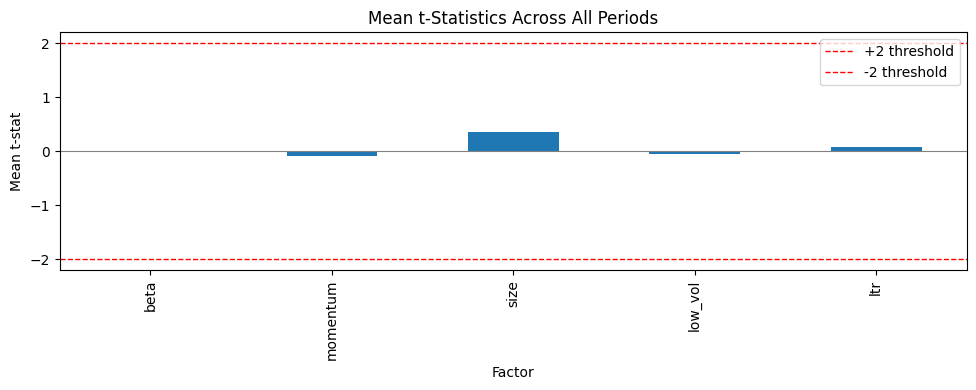

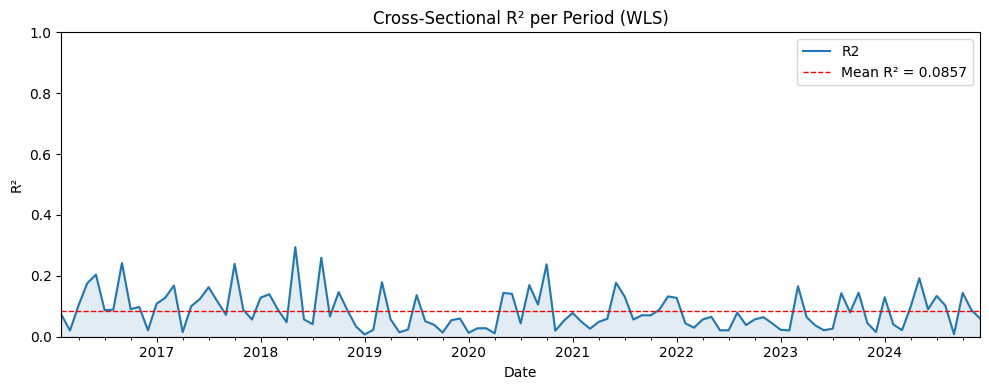

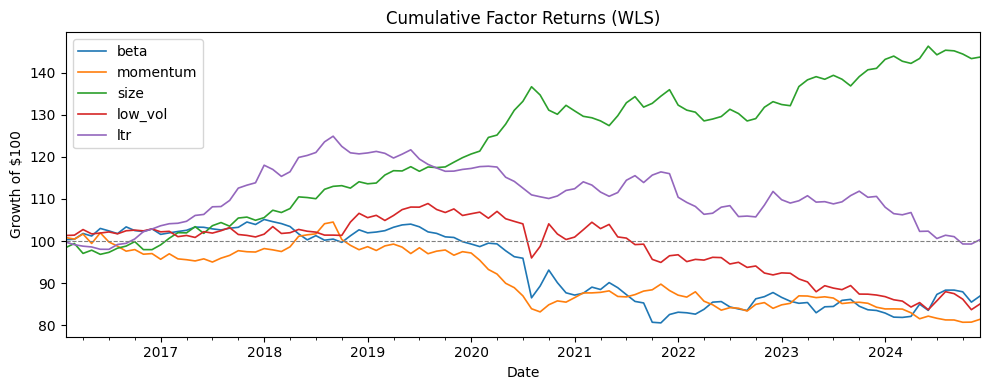

In [40]:
# =========================
# Plot 1 — Mean t-statistics
# =========================
fig1, ax1 = plt.subplots(figsize=(10, 4))

t_stats_A.mean().plot(kind="bar", ax=ax1)

ax1.axhline(2, color="red", linestyle="--", linewidth=1, label="+2 threshold")
ax1.axhline(-2, color="red", linestyle="--", linewidth=1, label="-2 threshold")
ax1.axhline(0, color="grey", linestyle="-", linewidth=0.8)

ax1.set_title("Mean t-Statistics Across All Periods")
ax1.set_ylabel("Mean t-stat")
ax1.set_xlabel("Factor")
ax1.legend()

fig1.tight_layout()
fig1.savefig("outputs/mean_tstats.png", dpi=300, bbox_inches="tight")

plt.show()


# =========================
# Plot 2 — R² time series
# =========================
fig2, ax2 = plt.subplots(figsize=(10, 4))

R2_A.plot(ax=ax2)

ax2.fill_between(
    R2_A.index,
    0,
    R2_A.values,
    alpha=0.15,
    color="steelblue"
)

ax2.axhline(
    R2_A.mean(),
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Mean R² = {R2_A.mean():.4f}"
)

ax2.set_title("Cross-Sectional R² per Period (WLS)")
ax2.set_ylabel("R²")
ax2.set_xlabel("Date")
ax2.set_ylim(0, 1)
ax2.legend()

fig2.tight_layout()
fig2.savefig("outputs/r2_timeseries.png", dpi=300, bbox_inches="tight")

plt.show()


# =========================
# Plot 3 — Cumulative factor returns
# =========================
cumulative = 100 * (1 + factor_returns_A).cumprod()

fig3, ax3 = plt.subplots(figsize=(10, 4))

for col in cumulative.columns:
    cumulative[col].plot(
        ax=ax3,
        linewidth=1.2,
        label=col
    )

ax3.axhline(100, color="grey", linestyle="--", linewidth=0.8)

ax3.set_title("Cumulative Factor Returns (WLS)")
ax3.set_ylabel("Growth of $100")
ax3.set_xlabel("Date")
ax3.legend(loc="upper left")

fig3.tight_layout()
fig3.savefig("outputs/cumulative_factor_returns.png", dpi=300, bbox_inches="tight")

plt.show()

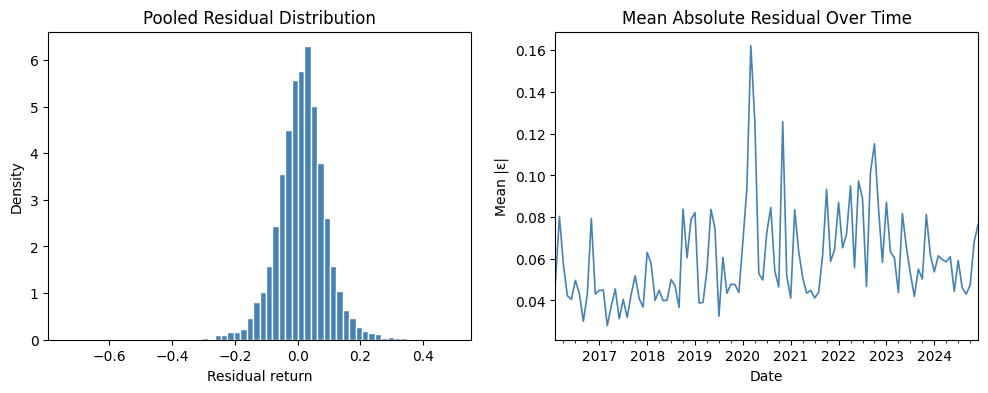

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — histogram of all residuals pooled
residuals_flat = residuals_A.values.flatten()
axes[0].hist(residuals_flat, bins=60, color="steelblue",
             edgecolor="white", density=True)
axes[0].set_title("Pooled Residual Distribution")
axes[0].set_xlabel("Residual return")
axes[0].set_ylabel("Density")

# Right — mean absolute residual over time
mean_abs_resid = residuals_A.abs().mean(axis=1)
mean_abs_resid.plot(ax=axes[1], color="steelblue", linewidth=1.2)
axes[1].set_title("Mean Absolute Residual Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Mean |ε|")

plt.savefig("outputs/residuals_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

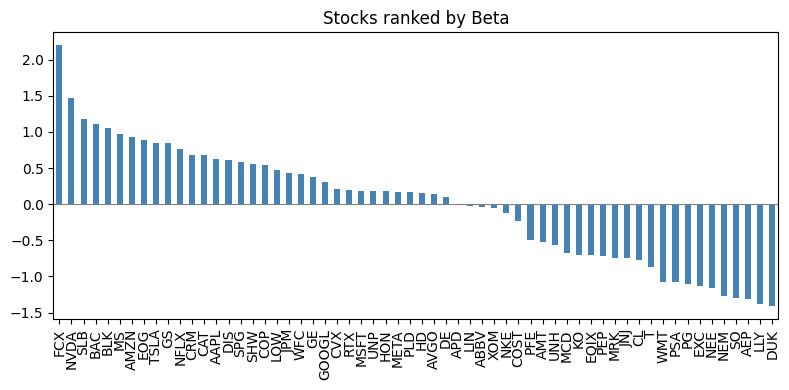

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
signals_processed["beta"].mean().sort_values(ascending=False).plot(kind = 'bar', color = "steelblue")
plt.axhline(0, color="grey", linestyle="-", linewidth=0.8)
plt.title("Stocks ranked by Beta")
plt.tight_layout()
plt.savefig("outputs/beta_ranking.png", dpi=300, bbox_inches="tight")
plt.show()


In [31]:
beta_filter = (signals_processed["beta"].mean() > 0)
beta_positive = signals_processed["beta"].columns[beta_filter]
np.save("beta_positive.npy", beta_positive)

In [32]:
factor_returns_A.to_csv("data/factor_returns_wls.csv")
residuals_A.to_csv("data/residuals_wls.csv")
R2_A.to_csv("data/R2_wls.csv")
t_stats_A.to_csv("data/t_stats_wls.csv")

### 3b. PCA 

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print(returns.isna().sum().sum())
R = returns.values
R_normalised = (R - R.mean(axis=0)) / R.std(axis=0)
print(R_normalised.shape)


0
(107, 60)


In [34]:
pca_full = PCA(n_components = None) # General scan
pca_full.fit(R_normalised)

eigenvalues = pca_full.explained_variance_ # (60,) Eigenvalues in descending order
explained_var = pca_full.explained_variance_ratio_ # (60,) % Variance each PC
eigenvectors = pca_full.components_ # (60, 60) rows = PCs


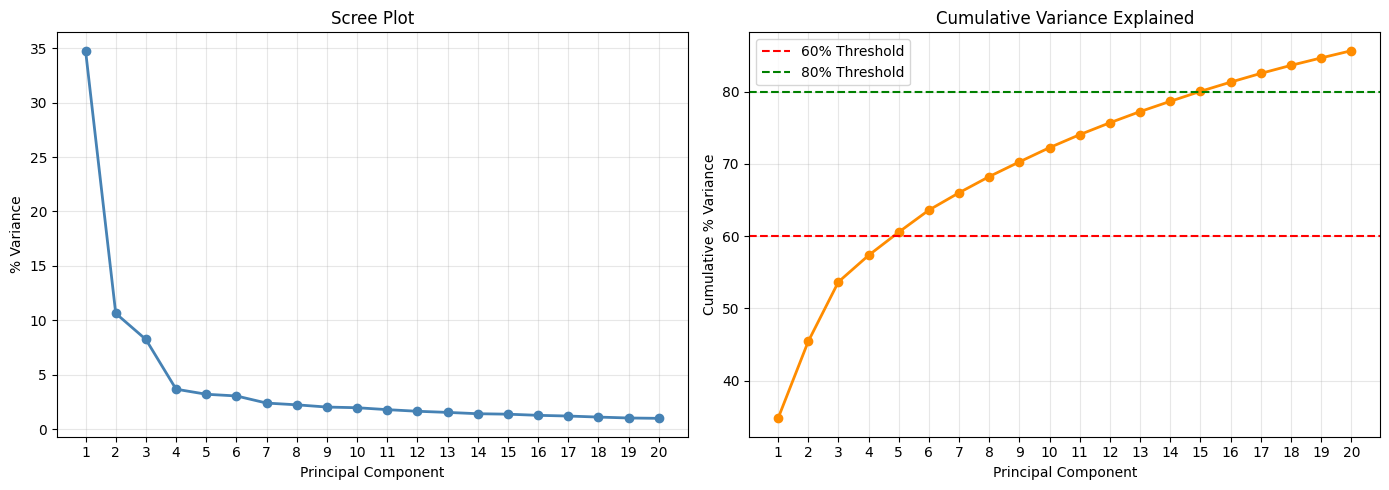

In [44]:
fig, ax = plt.subplots(1,2, figsize = (14,5))

n_display = 20 # first 20 PCs

ax[0].plot(
    range(1, n_display + 1), 
    explained_var[:n_display] * 100,
    marker = 'o', lw = 2, color = "steelblue"
)
ax[0].set_xlabel("Principal Component")
ax[0].set_xticks(range(1, n_display + 1))
ax[0].set_ylabel("% Variance")
ax[0].set_title("Scree Plot")
ax[0].grid(alpha=0.3)

cumulative_var = np.cumsum(explained_var) 
ax[1].plot(
    range(1, n_display + 1), 
    cumulative_var[:n_display] * 100,
    marker = 'o', lw = 2, color = "darkorange"
)
ax[1].axhline(60, color = "r", linestyle = '--', label = "60% Threshold")
ax[1].axhline(80, color = "g", linestyle = '--', label = "80% Threshold")
ax[1].set_xlabel("Principal Component")
ax[1].set_xticks(range(1, n_display + 1))
ax[1].set_ylabel("Cumulative % Variance")
ax[1].set_title("Cumulative Variance Explained")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/scree_plot.png", dpi=300, bbox_inches="tight")

In [36]:
# Set K and refit PCA
K = 6
pca = PCA(n_components = K)
pca.fit(R_normalised)
B_pca = pca.components_.T # shape (60, K) Eigenvectors as columns
F_pca = pca.transform(R_normalised) # shape (T, K) Factor returns time series (synthetic porfolio)
pc_labels = [f"PC{i+1}" for i in range(K)]

B_pca_df = pd.DataFrame(B_pca, index = tickers, columns = pc_labels)
F_pca_df = pd.DataFrame(F_pca, index = dates, columns = pc_labels)

print(B_pca_df.shape)
print(F_pca_df.shape)


(60, 6)
(107, 6)


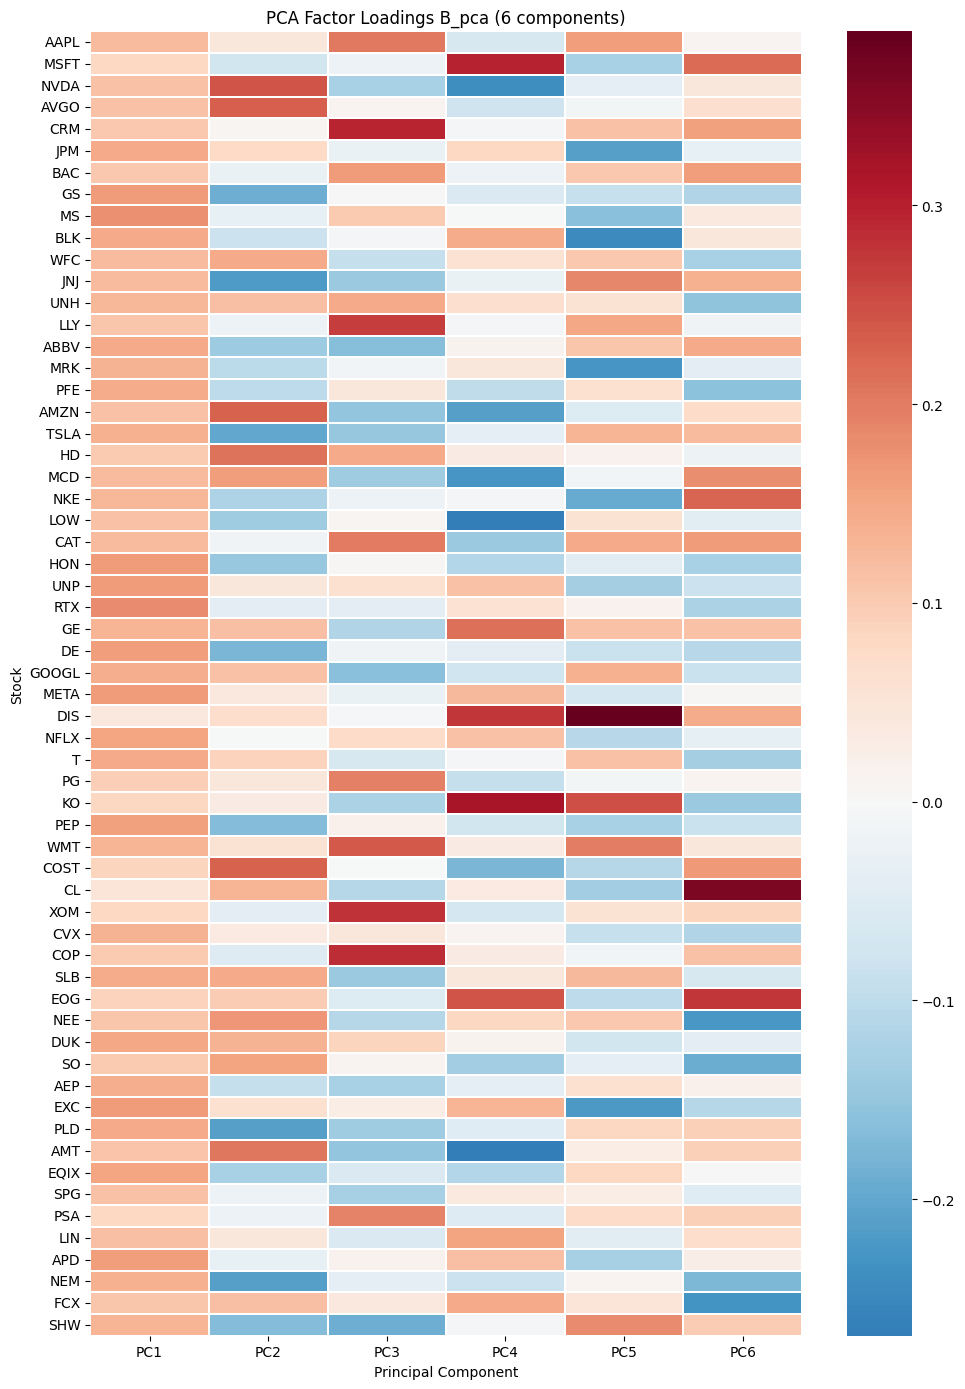

In [45]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 14))

sns.heatmap(
    B_pca_df, 
    cmap = 'RdBu_r', 
    center = 0, 
    annot = False, 
    linewidths = 0.3, 
    ax = ax
)

ax.set_title(f'PCA Factor Loadings B_pca ({K} components)')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Stock')

plt.tight_layout()
plt.savefig("outputs/pca_loadings_heatmap.png", dpi=300, bbox_inches="tight")

In [103]:
# PC1 market factor - same sign, similar magnitude
# PC2 sector 
tickers_dict = {
    "Information Technology": ["AAPL", "MSFT", "NVDA", "AVGO", "CRM"],  # High momentum, growth factor exposure
    "Financials": ["JPM", "BAC", "GS", "MS", "BLK", "WFC"],             # Value factor, rate sensitivity
    "Health Care": ["JNJ", "UNH", "LLY", "ABBV", "MRK", "PFE"],         # Defensive, quality factor
    "Consumer Discretionary": ["AMZN", "TSLA", "HD", "MCD", "NKE", "LOW"], # Cyclical, momentum variation
    "Industrials": ["CAT", "HON", "UNP", "RTX", "GE", "DE"],            # Classic value/quality mix
    "Communication Services": ["GOOGL", "META", "DIS", "NFLX", "T"],    # Growth vs. value spread
    "Consumer Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL"],       # Low vol, defensive
    "Energy": ["XOM", "CVX", "COP", "SLB", "EOG"],                      # Value, commodity beta
    "Utilities": ["NEE", "DUK", "SO", "AEP", "EXC"],                    # Low vol, yield factor
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "PSA"],                # Yield, rate sensitivity
    "Materials": ["LIN", "APD", "NEM", "FCX", "SHW"],                   # Cyclical, commodity exposure
}


sector_map = {ticker: sector for sector, tickers in tickers_dict.items() for ticker in tickers}
sector_df = pd.DataFrame({'Sector': sector_map})
pc2_by_sector_df = sector_df.join(B_pca_df["PC2"])
pc2_by_sector_df = pc2_by_sector_df.groupby("Sector").agg(
    PC2 = ("PC2", "mean"), 
    std = ("PC2", "std"),
).sort_values("PC2", ascending=False)
pc2_by_sector_df


,PC2,std
Sector,,
Information Technology,0.089447,0.139658
Utilities,0.087335,0.107734
Communication Services,0.062671,0.043899
Consumer Staples,0.054271,0.130370
Energy,0.037845,0.085441
Consumer Discretionary,0.023549,0.195516
Financials,-0.017407,0.117892
Real Estate,-0.033616,0.156163
Industrials,-0.036397,0.111813


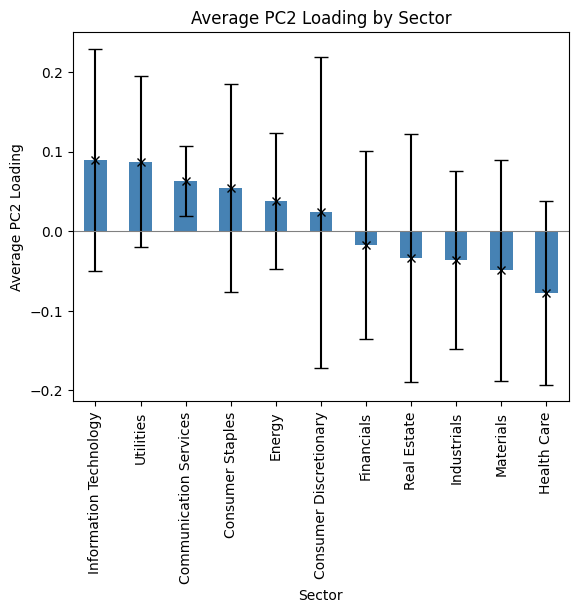

In [109]:
pc2_by_sector_df.plot(kind = 'bar', y = "PC2", legend = False, color = "steelblue")

plt.errorbar(pc2_by_sector_df.index, pc2_by_sector_df["PC2"], yerr = pc2_by_sector_df["std"], marker = 'x', capsize = 5, color = "black", linestyle = "None")
plt.axhline(0, color="grey", linestyle="-", linewidth=0.8)
plt.title("Average PC2 Loading by Sector")
plt.ylabel("Average PC2 Loading")
plt.xlabel("Sector")

plt.savefig("outputs/pc2_sector_loadings.png", dpi=300, bbox_inches="tight")

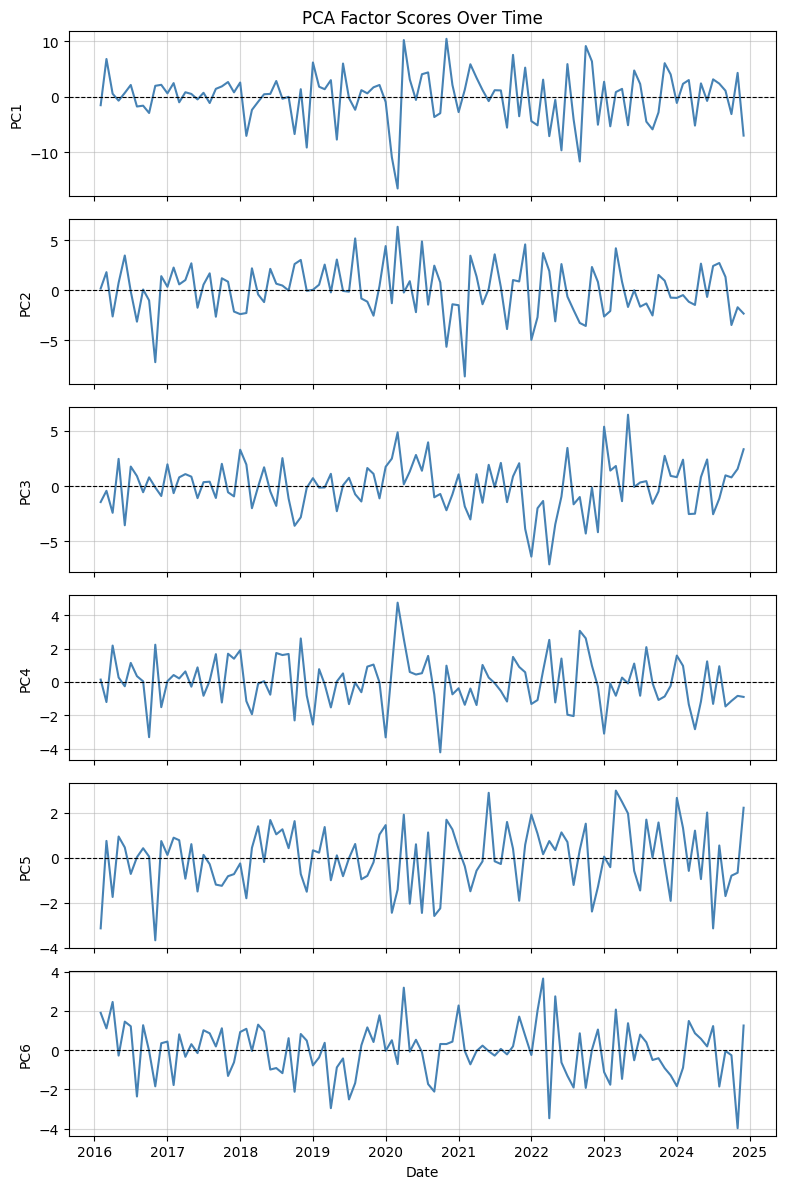

In [118]:
# Factor scores over time
fig, ax = plt.subplots(K, 1, figsize=(8, 2 * K), sharex=True)

for k, pc in enumerate(pc_labels):
    ax[k].plot(F_pca_df.index, F_pca_df[pc], lw = 1.5, color = "steelblue")
    ax[k].axhline(0, color = 'black', lw = 0.8, ls = '--')
    ax[k].set_ylabel(pc)
    ax[k].grid(True, alpha=0.5)

ax[0].set_title('PCA Factor Scores Over Time')
ax[-1].set_xlabel('Date')

plt.tight_layout()
plt.savefig("outputs/pca_factor_scores_over_time.png", dpi=300, bbox_inches="tight")

In [120]:
B_pca_df.to_csv("data/pca_loadings.csv")
F_pca_df.to_csv("data/pca_factor_scores.csv")

pd.DataFrame({
    "eigenvalues": eigenvalues,
    "explained_var_pct": explained_var * 100, 
    "cumulative_pct": cumulative_var * 100
}).to_csv("data/pca_eigenvalues.csv", index_label = "PC")

In [ ]:
# Remind what is B and F
# returns were normalised before PCA, so factor scores are in standardised return units (z-scores)

### 3c. Compare PCA factors vs fundamental factors

## 5. Covariance Matrix Estimation

## 6. Validation and Diagnostics

IC, ICIR, t-stats, residual PCA check

## 7. Results and Visualisations